In [22]:
%pip install xlrd

################ Load data ready for nested logit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


Note: you may need to restart the kernel to use updated packages.


In [2]:
################ Load data ready for nested logit
df = pd.read_csv('data_with_IV.csv')

# Generate nesting_id
df['nesting_ids'] = pd.factorize(df['fuel_type'])[0]

# Generate log of charging station stock
df['log_charging_IV'] = np.log(df['charging_stations_stock_lag']) 

# Create indicator for electric vehicles
df['is_electric'] = df['type'].apply(lambda x: 1 if x == '国产新能源乘用车' else 0)

# Make year an object variable
df['year'] = df['year'].astype(str)

# Other data
charging_df = pd.read_csv('Data Cleaning/charging_station_data.csv')
global_bev = pd.read_excel('C:/Users/Lenovo/Desktop/Dissertaion/China Data/Other/global_bev.xls')
global_phev = pd.read_excel('C:/Users/Lenovo/Desktop/Dissertaion/China Data/Other/global_phev.xls')

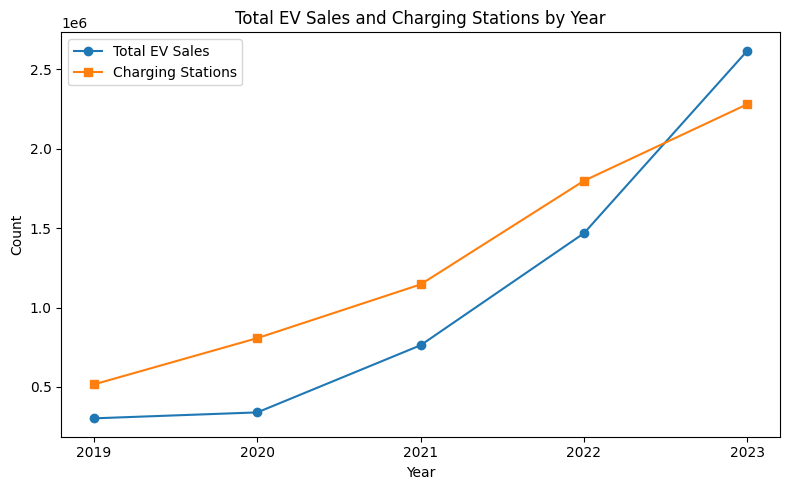

In [23]:
################ Plot sum of total EV sales and charging stations by year to compare trend

# Ensure year columns are integer type before grouping
df['year'] = df['year'].astype(int)
charging_df['year'] = charging_df['year'].astype(int)

# Group by year and sum EV sales and charging stations
ev_sales_sum = (
    df[df['fuel_type'].isin(['BEV', 'PHEV'])]
    .groupby('year')['sales']
    .sum()
)
charging_stock_sum = charging_df.groupby('year')['公共充电桩保有量（台）'].sum()

# Indices are already int, so no need to convert again

# Align years for plotting (intersection)
common_years = sorted(set(ev_sales_sum.index) & set(charging_stock_sum.index))
ev_sales_plot = ev_sales_sum.loc[common_years]
charging_stock_plot = charging_stock_sum.loc[common_years]

# Plot both on the same figure
plt.figure(figsize=(8, 5))
plt.plot(ev_sales_plot.index, ev_sales_plot.values, label='Total EV Sales', marker='o')
plt.plot(charging_stock_plot.index, charging_stock_plot.values, label='Charging Stations', marker='s')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Total EV Sales and Charging Stations by Year')
plt.legend()
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))  # Force integer ticks
plt.tight_layout()
plt.show()